In [ ]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_student_data, validate_columns

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = load_student_data()

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 395
Columns: 33


In [4]:
validate_columns(df)

print("Column validation passed.")

Column validation passed.


In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 395
Number of columns: 33


In [8]:
print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns:
1. school
2. sex
3. age
4. address
5. famsize
6. Pstatus
7. Medu
8. Fedu
9. Mjob
10. Fjob
11. reason
12. guardian
13. traveltime
14. studytime
15. failures
16. schoolsup
17. famsup
18. paid
19. activities
20. nursery
21. higher
22. internet
23. romantic
24. famrel
25. freetime
26. goout
27. Dalc
28. Walc
29. health
30. absences
31. G1
32. G2
33. G3


In [9]:
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [11]:
missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing Percentage


In [14]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
df.describe(include="all")

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,...,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,...,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000


In [15]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [16]:
categorical_columns = df.select_dtypes(
    exclude=np.number
).columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [17]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


school
<StringArray>
['GP', 'MS']
Length: 2, dtype: str

sex
<StringArray>
['F', 'M']
Length: 2, dtype: str

address
<StringArray>
['U', 'R']
Length: 2, dtype: str

famsize
<StringArray>
['GT3', 'LE3']
Length: 2, dtype: str

Pstatus
<StringArray>
['A', 'T']
Length: 2, dtype: str

Mjob
<StringArray>
['at_home', 'health', 'other', 'services', 'teacher']
Length: 5, dtype: str

Fjob
<StringArray>
['teacher', 'other', 'services', 'health', 'at_home']
Length: 5, dtype: str

reason
<StringArray>
['course', 'other', 'home', 'reputation']
Length: 4, dtype: str

guardian
<StringArray>
['mother', 'father', 'other']
Length: 3, dtype: str

schoolsup
<StringArray>
['yes', 'no']
Length: 2, dtype: str

famsup
<StringArray>
['no', 'yes']
Length: 2, dtype: str

paid
<StringArray>
['no', 'yes']
Length: 2, dtype: str

activities
<StringArray>
['no', 'yes']
Length: 2, dtype: str

nursery
<StringArray>
['yes', 'no']
Length: 2, dtype: str

higher
<StringArray>
['yes', 'no']
Length: 2, dtype: str

internet
<

In [18]:
expected_ranges = {
    "age": (15, 22),
    "Medu": (0, 4),
    "Fedu": (0, 4),
    "traveltime": (1, 4),
    "studytime": (1, 4),
    "failures": (0, 4),
    "famrel": (1, 5),
    "freetime": (1, 5),
    "goout": (1, 5),
    "Dalc": (1, 5),
    "Walc": (1, 5),
    "health": (1, 5),
    "absences": (0, 93),
    "G1": (0, 20),
    "G2": (0, 20),
    "G3": (0, 20)
}


for column, (minimum, maximum) in expected_ranges.items():

    invalid_rows = df[
        (df[column] < minimum) |
        (df[column] > maximum)
    ]

    print(
        f"{column}: "
        f"{len(invalid_rows)} invalid values"
    )

age: 0 invalid values
Medu: 0 invalid values
Fedu: 0 invalid values
traveltime: 0 invalid values
studytime: 0 invalid values
failures: 0 invalid values
famrel: 0 invalid values
freetime: 0 invalid values
goout: 0 invalid values
Dalc: 0 invalid values
Walc: 0 invalid values
health: 0 invalid values
absences: 0 invalid values
G1: 0 invalid values
G2: 0 invalid values
G3: 0 invalid values


In [19]:
expected_categories = {
    "school": {"GP", "MS"},
    "sex": {"F", "M"},
    "address": {"U", "R"},
    "famsize": {"LE3", "GT3"},
    "Pstatus": {"T", "A"},
    "Mjob": {"teacher", "health", "services", "at_home", "other"},
    "Fjob": {"teacher", "health", "services", "at_home", "other"},
    "reason": {"home", "reputation", "course", "other"},
    "guardian": {"mother", "father", "other"},
    "schoolsup": {"yes", "no"},
    "famsup": {"yes", "no"},
    "paid": {"yes", "no"},
    "activities": {"yes", "no"},
    "nursery": {"yes", "no"},
    "higher": {"yes", "no"},
    "internet": {"yes", "no"},
    "romantic": {"yes", "no"}
}

for column, expected_values in expected_categories.items():

    actual_values = set(df[column].dropna().unique())

    unexpected_values = actual_values - expected_values

    print(f"{column}:")
    print("  Unexpected values:", unexpected_values)

school:
  Unexpected values: set()
sex:
  Unexpected values: set()
address:
  Unexpected values: set()
famsize:
  Unexpected values: set()
Pstatus:
  Unexpected values: set()
Mjob:
  Unexpected values: set()
Fjob:
  Unexpected values: set()
reason:
  Unexpected values: set()
guardian:
  Unexpected values: set()
schoolsup:
  Unexpected values: set()
famsup:
  Unexpected values: set()
paid:
  Unexpected values: set()
activities:
  Unexpected values: set()
nursery:
  Unexpected values: set()
higher:
  Unexpected values: set()
internet:
  Unexpected values: set()
romantic:
  Unexpected values: set()


In [22]:
print(df["G3"].describe())
print("Unique G3 values:")
print(sorted(df["G3"].unique()))
print("G3 frequency:")
print(df["G3"].value_counts().sort_index())

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64
Unique G3 values:
[np.int64(0), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
G3 frequency:
G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


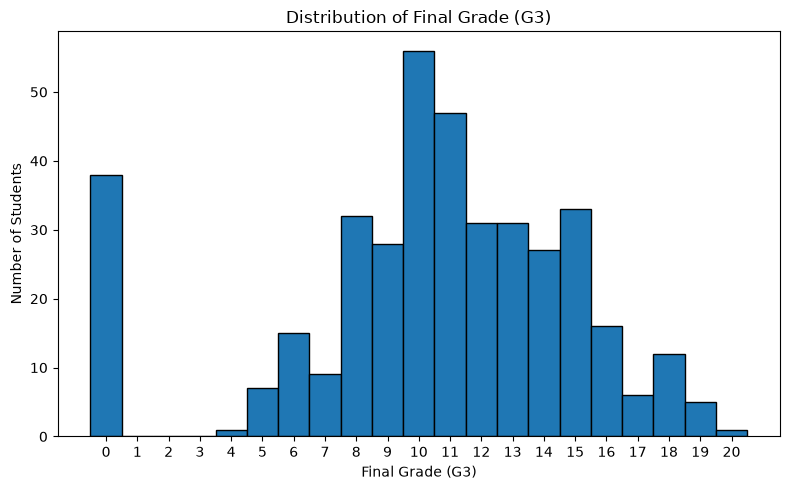

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["G3"],
    bins=np.arange(-0.5, 21.5, 1),
    edgecolor="black"
)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.xticks(range(0, 21))

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "g3_distribution.png",
    dpi=300
)

plt.show()

<Figure size 800x500 with 0 Axes>

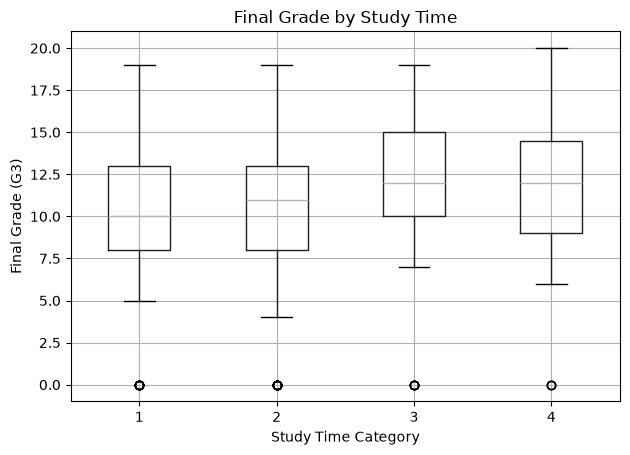

In [24]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="G3",
    by="studytime"
)

plt.title("Final Grade by Study Time")
plt.suptitle("")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "studytime_vs_g3.png",
    dpi=300
)

plt.show()

<Figure size 800x500 with 0 Axes>

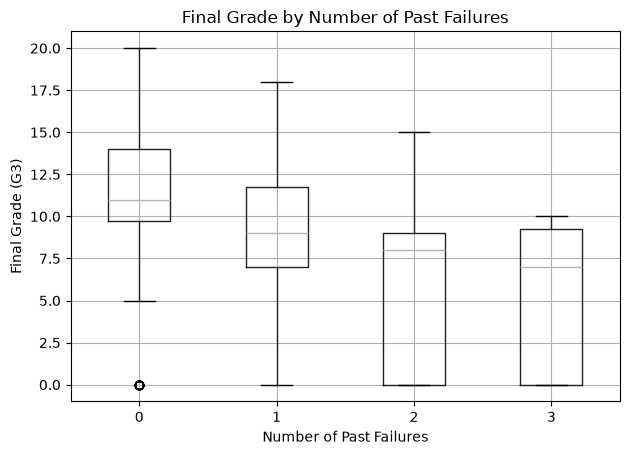

In [25]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="G3",
    by="failures"
)

plt.title("Final Grade by Number of Past Failures")
plt.suptitle("")
plt.xlabel("Number of Past Failures")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "failures_vs_g3.png",
    dpi=300
)

plt.show()

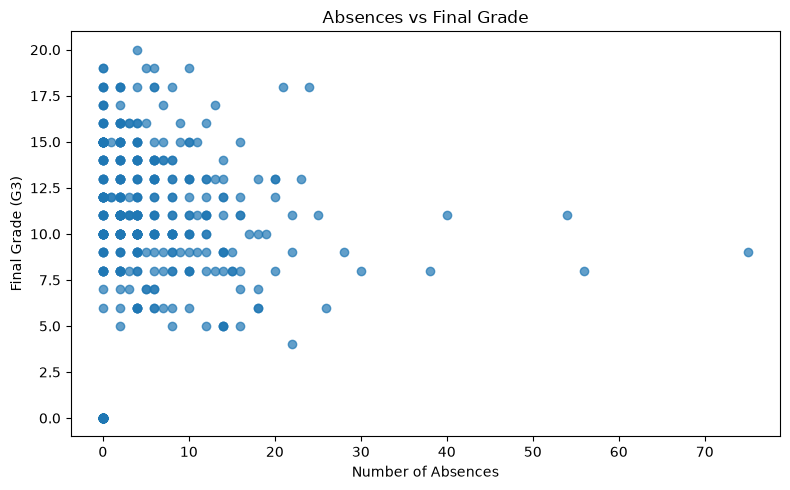

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["absences"],
    df["G3"],
    alpha=0.7
)

plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "absences_vs_g3.png",
    dpi=300
)

plt.show()

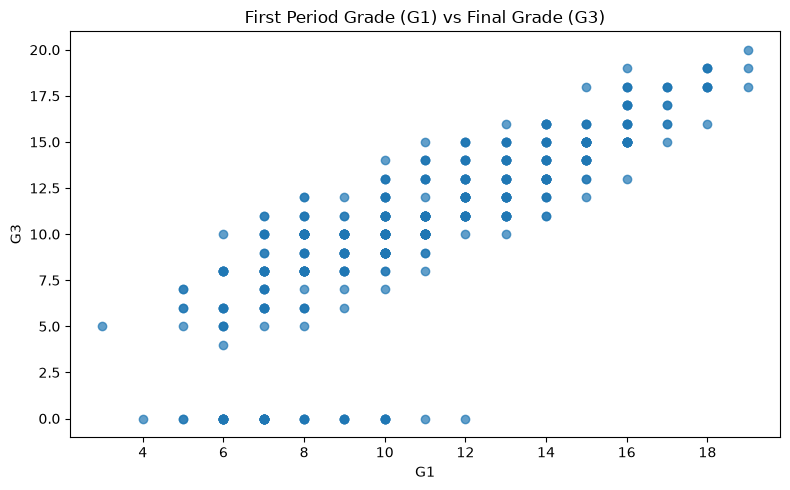

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["G1"],
    df["G3"],
    alpha=0.7
)

plt.title("First Period Grade (G1) vs Final Grade (G3)")
plt.xlabel("G1")
plt.ylabel("G3")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "g1_g3_relationship.png",
    dpi=300
)

plt.show()

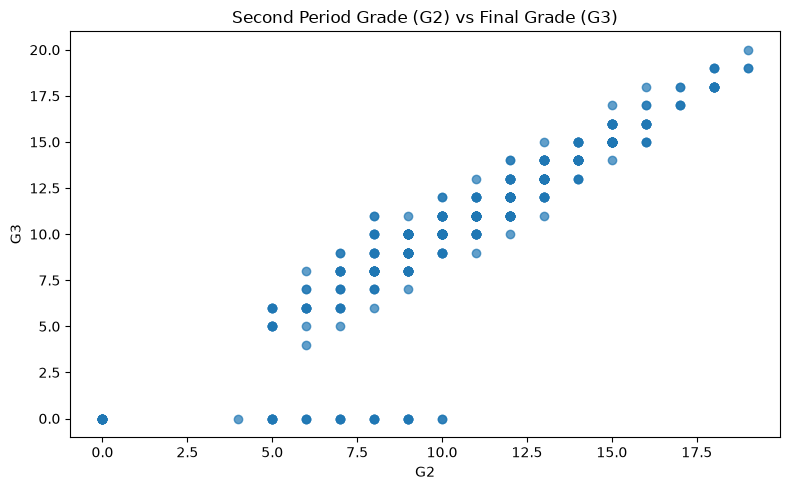

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["G2"],
    df["G3"],
    alpha=0.7
)

plt.title("Second Period Grade (G2) vs Final Grade (G3)")
plt.xlabel("G2")
plt.ylabel("G3")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "g2_g3_relationship.png",
    dpi=300
)

plt.show()

In [29]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix["G3"].sort_values(
    ascending=False
)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

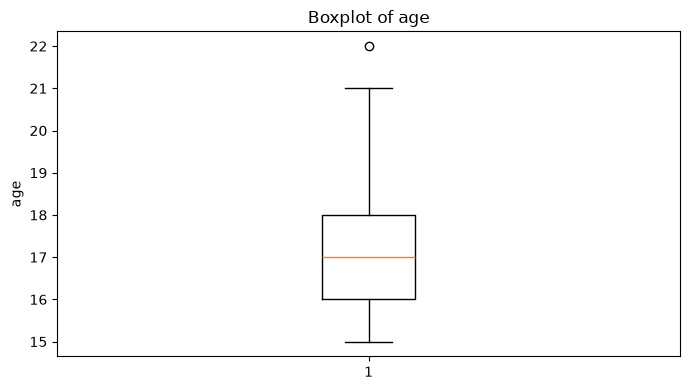

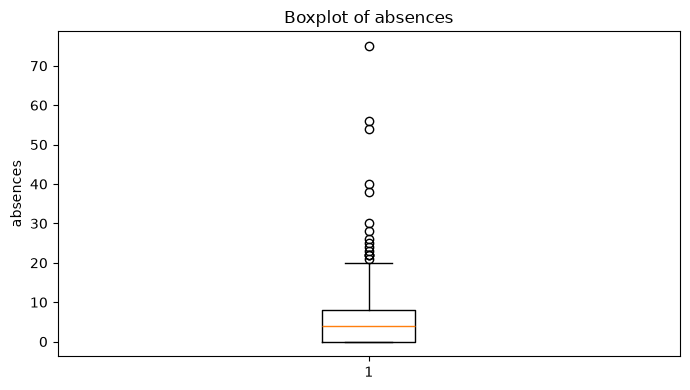

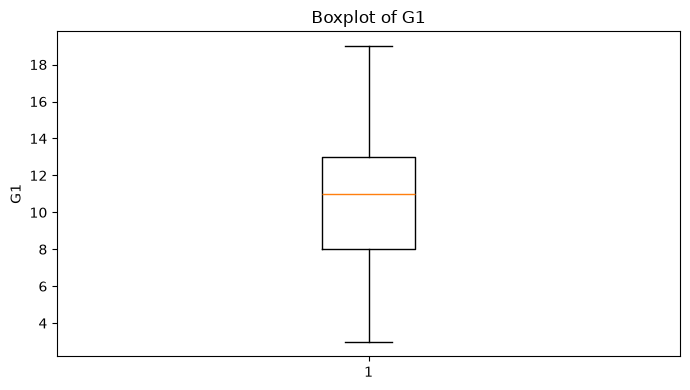

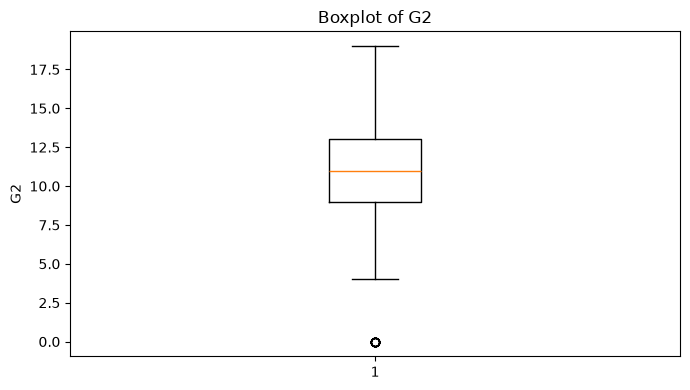

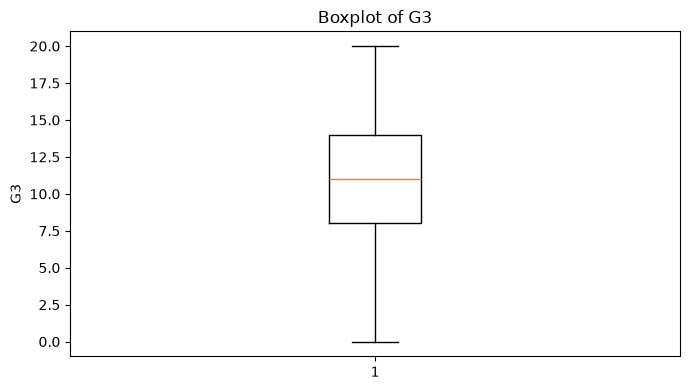

In [31]:
outlier_columns = [
    "age",
    "absences",
    "G1",
    "G2",
    "G3"
]

for column in outlier_columns:

    plt.figure(figsize=(7, 4))

    plt.boxplot(df[column])

    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)

    plt.tight_layout()

    plt.savefig(
        PROJECT_ROOT / "figures" / f"{column}_boxplot.png",
        dpi=300
    )

    plt.show()

In [33]:
def find_iqr_outliers(dataframe, column):

    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = dataframe[
        (dataframe[column] < lower_bound) |
        (dataframe[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound

for column in ["age", "absences", "G1", "G2", "G3"]:

    outliers, lower, upper = find_iqr_outliers(
        df,
        column
    )

    print(f"\n{column}")
    print(f"Lower bound: {lower:.2f}")
    print(f"Upper bound: {upper:.2f}")
    print(f"Number of IQR outliers: {len(outliers)}")


age
Lower bound: 13.00
Upper bound: 21.00
Number of IQR outliers: 1

absences
Lower bound: -12.00
Upper bound: 20.00
Number of IQR outliers: 15

G1
Lower bound: 0.50
Upper bound: 20.50
Number of IQR outliers: 0

G2
Lower bound: 3.00
Upper bound: 19.00
Number of IQR outliers: 13

G3
Lower bound: -1.00
Upper bound: 23.00
Number of IQR outliers: 0


In [34]:
def check_numeric_ranges(df, ranges):

    results = []

    for column, (minimum, maximum) in ranges.items():

        invalid_count = (
            (df[column] < minimum) |
            (df[column] > maximum)
        ).sum()

        results.append({
            "Column": column,
            "Expected Min": minimum,
            "Expected Max": maximum,
            "Invalid Values": invalid_count
        })

    return pd.DataFrame(results)

range_results = check_numeric_ranges(
    df,
    expected_ranges
)

range_results

,Column,Expected Min,Expected Max,Invalid Values
0,age,15,22,0
1,Medu,0,4,0
2,Fedu,0,4,0
3,traveltime,1,4,0
4,studytime,1,4,0
5,failures,0,4,0
6,famrel,1,5,0
7,freetime,1,5,0
8,goout,1,5,0
9,Dalc,1,5,0


In [35]:
audit_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

audit_report

,Column,Data Type,Missing Values,Unique Values
0,school,str,0,2
1,sex,str,0,2
2,age,int64,0,8
3,address,str,0,2
4,famsize,str,0,2
5,Pstatus,str,0,2
6,Medu,int64,0,5
7,Fedu,int64,0,5
8,Mjob,str,0,5
9,Fjob,str,0,5


EDA Summary: Student Math Performance Dataset

The dataset contains 395 students and 33 variables covering their background, lifestyle, study habits, and academic performance. Overall, the data is clean, with no missing values, duplicates, or obvious errors.

The strongest factor linked to final grades is previous academic performance. Students who did well in the earlier grading periods were much more likely to achieve higher final grades. Past failures also have a clear impact, with final grades generally decreasing as the number of previous failures increases.

Study time has a positive effect, but it is fairly small compared with previous grades and failure history. Interestingly, absences show almost no clear relationship with final grades, despite what we might expect.

One thing worth paying attention to is the number of students with a final grade of zero, which may represent students who dropped out or did not take the final exam rather than students who simply performed poorly. There are also a few students with unusually high absences, ages, or mid-year grades, but these don't appear to be data errors.

Overall, the dataset is clean and ready for modeling. Previous grades and failure history provide the strongest signals, while study time has a smaller effect and absences don't seem very useful on their own.